In [1]:
import pandas as pd
import json
import numpy as np
import tarfile
from collections import Counter
import matplotlib.pyplot as plt
import time
from openai import OpenAI
from tqdm import tqdm
from datasets import load_dataset
client = OpenAI(api_key=open('key.txt').read())
from simpletransformers.classification import ClassificationModel
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def evaluate(df, y_true_column, y_test_column, matrix=True):
	# Evaluate the performance of the model
	from sklearn.metrics import f1_score
	import matplotlib.pyplot as plt
	from sklearn.metrics import confusion_matrix, classification_report

	# Get the true labels
	y_true = df[y_true_column].to_list()
	LABELS = list(df[y_true_column].unique())
	y_pred = df[y_test_column].to_list()

	# Calculate the scores
	macro = f1_score(y_true, y_pred, labels=LABELS, average="macro")
	micro = f1_score(y_true, y_pred, labels=LABELS,  average="micro")
	print(f"Macro f1: {macro:0.3}, Micro f1: {micro:0.3}")

	scores = {"micro_F1": micro, "macro_F1": macro}

	#print(classification_report(y_true, y_pred))

	if matrix == True:
		# Plot the confusion matrix:
		cm = confusion_matrix(y_true, y_pred, labels=LABELS)
		plt.figure(figsize=(9, 9))
		plt.imshow(cm, cmap="Oranges")
		for (i, j), z in np.ndenumerate(cm):
			plt.text(j, i, '{:d}'.format(z), ha='center', va='center')
		classNames = LABELS
		plt.ylabel('True label')
		plt.xlabel('Predicted label')
		tick_marks = np.arange(len(classNames))
		plt.xticks(tick_marks, classNames, rotation=90)
		plt.yticks(tick_marks, classNames)
		#plt.title(f"{model_name}")

		plt.tight_layout()
		fig1 = plt.gcf()
		plt.show()
		plt.draw()
	return scores

# Open the Datasets

In [3]:
# Open the X-GENRE test from the HuggingFace
test = load_dataset("TajaKuzman/X-GENRE-text-genre-dataset", "test")

x_genre_test = pd.DataFrame(test["train"])

x_genre_test.head(2)

,text,labels,dataset,language
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English


In [4]:
# Open the datasets
en_ginco = pd.read_json("datasets/base-datasets/EN-GINCO.jsonl", 
lines=True)

display(en_ginco.head(2))

x_ginco = pd.read_json("datasets/X-GINCO.jsonl", orient="records", lines=True)
display(x_ginco.head(2))

,text,labels,dataset,language
0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,EN-GINCO,English
1,Why graft thrives in postconflict zones <p> A ...,News,EN-GINCO,English


,text,labels,language,dataset,text_id,translation
0,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...",News,Maltese,MaCoCu,macocu.mt.402244,"Angelo Chetcuti, will be replacing Bjorn Vassa..."
1,Poltergeist jirreferi għal fenomeni oħra tal-m...,Opinion/Argumentation,Maltese,MaCoCu,macocu.mt.377203,"Poltergeist refers to other woman's phenomena,..."


# Apply Models on Them

In [ ]:
# Code for applying newly fine-tuned models, locally saved

def apply_model(df, model_dir):
	model = ClassificationModel("xlmroberta", f"models/{model_dir}")

	# Calculate the model's predictions on test
	def make_prediction(input_string):
		return model.predict([input_string])[0][0]

	y_pred = df.text.apply(make_prediction)
	df[f"pred_{model_dir}"] = y_pred

	print("Prediction finished.")

	return df

In [28]:
x_genre_test = apply_model(x_genre_test, "Student-X-GENRE-v3")
x_genre_test.head(4)

/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/simpletransformers/classification/classification_model.py:484: UserWarning: use_multiprocessing automatically disabled as xlmroberta fails when using multiprocessing for feature conversion.
  warnings.warn(


Prediction finished.


,text,labels,dataset,language,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English,Forum,Forum,Forum
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English,Instruction,Forum,Instruction
2,Almost a quarter of Republicans think Obama 'm...,News,CORE,English,News,News,News
3,Showcase Main menu You are here The Gatekeeper...,Prose/Lyrical,CORE,English,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical


In [29]:
en_ginco = apply_model(en_ginco, "Student-X-GENRE-v3")
en_ginco.head(4)

/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/simpletransformers/classification/classification_model.py:484: UserWarning: use_multiprocessing automatically disabled as xlmroberta fails when using multiprocessing for feature conversion.
  warnings.warn(


Prediction finished.


,text,labels,dataset,language,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3
0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,EN-GINCO,English,Promotion,Promotion,Promotion
1,Why graft thrives in postconflict zones <p> A ...,News,EN-GINCO,English,News,News,News
2,Social Trip <p> On the evening of Wednesday 15...,Promotion,EN-GINCO,English,Promotion,Promotion,Promotion
3,If the burner cap on your hob is not looking l...,Promotion,EN-GINCO,English,Promotion,Promotion,Promotion


In [30]:
x_ginco = apply_model(x_ginco, "Student-X-GENRE-v3")
x_ginco.head(4)

/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/simpletransformers/classification/classification_model.py:484: UserWarning: use_multiprocessing automatically disabled as xlmroberta fails when using multiprocessing for feature conversion.
  warnings.warn(


Prediction finished.


,text,labels,language,dataset,text_id,translation,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3
0,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...",News,Maltese,MaCoCu,macocu.mt.402244,"Angelo Chetcuti, will be replacing Bjorn Vassa...",News,News,News
1,Poltergeist jirreferi għal fenomeni oħra tal-m...,Opinion/Argumentation,Maltese,MaCoCu,macocu.mt.377203,"Poltergeist refers to other woman's phenomena,...",Prose/Lyrical,Prose/Lyrical,Prose/Lyrical
2,Chrysler: Brand ta 'lussu jew le? \n\nBrand ji...,Opinion/Argumentation,Maltese,MaCoCu,macocu.mt.109995,Chrysler: Luxury brand or not?\n\nBrand moves ...,Opinion/Argumentation,Opinion/Argumentation,Opinion/Argumentation
3,Kif tneħħi hangover sewwa u bla perikolu \n\nH...,Instruction,Maltese,MaCoCu,macocu.mt.213859,How to remove a proper and safe hangover\n\nHa...,Information/Explanation,Opinion/Argumentation,Information/Explanation


### Add published X-GENRE model to the evaluation

In [31]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=5

from transformers import AutoTokenizer
import sys
import torch
import json
from scipy.special import softmax
from transformers import AutoModelForSequenceClassification
import argparse
import pandas as pd

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=5


In [32]:
def predict_genre(df):

	texts = df["text"].to_list()

	prediction_list = []

	model = AutoModelForSequenceClassification.from_pretrained("classla/xlm-roberta-base-multilingual-text-genre-classifier")
	model.to("cuda:0")

	tokenizer = AutoTokenizer.from_pretrained("classla/xlm-roberta-base-multilingual-text-genre-classifier")

	labels = ["Other", "Information/Explanation", "News", "Instruction", "Opinion/Argumentation", "Forum", "Prose/Lyrical", "Legal", "Promotion"]

	def transcode(logit):
		cats=sorted(zip(labels,softmax(logit)),key=lambda x:-x[1])
		label=cats[0][0]
		return label

	inputs = tokenizer(texts, max_length=512, truncation=True, padding=True, return_tensors="pt").to("cuda:0")

	with torch.no_grad():
		logits = model(**inputs).logits

	for idx in range(len(logits)):
		current_logit = logits[idx].tolist()
		prediction_list.append(transcode(current_logit))

	df[f"official-x-genre_pred"] = prediction_list

	return df


In [33]:
for dataset in ["en_ginco", "x_ginco", "x_genre_test"]:
	print(dataset)
	df_dict = {"en_ginco": en_ginco, "x_ginco": x_ginco, "x_genre_test": x_genre_test}
	df_dict[dataset] = predict_genre(df_dict[dataset])
	display(df_dict[dataset].head(2))

en_ginco


,text,labels,dataset,language,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3,official-x-genre_pred
0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,EN-GINCO,English,Promotion,Promotion,Promotion,Forum
1,Why graft thrives in postconflict zones <p> A ...,News,EN-GINCO,English,News,News,News,News


x_ginco


,text,labels,language,dataset,text_id,translation,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3,official-x-genre_pred
0,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...",News,Maltese,MaCoCu,macocu.mt.402244,"Angelo Chetcuti, will be replacing Bjorn Vassa...",News,News,News,News
1,Poltergeist jirreferi għal fenomeni oħra tal-m...,Opinion/Argumentation,Maltese,MaCoCu,macocu.mt.377203,"Poltergeist refers to other woman's phenomena,...",Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical


x_genre_test


,text,labels,dataset,language,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3,official-x-genre_pred
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English,Forum,Forum,Forum,Forum
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English,Instruction,Forum,Instruction,Forum


### Add GPT-5 to the evaluation

In [5]:
def predict_gpt(df, gpt_model):

	responses = []
	
	texts = df["text"].to_list()

	labels_dict = {
		0: "Other",
		1: "Information/Explanation",
		2: "News",
		3: "Instruction",
		4: "Opinion/Argumentation",
		5: "Forum",
		6: "Prose/Lyrical",
		7: "Legal",
		8: "Promotion"
	}

	label_dict_with_description_ext = {
			"Information/Explanation - An objective text that describes or presents an event, a person, a thing, a concept etc. Its main purpose is to inform the reader about something. Common features: objective/factual, explanation/definition of a concept (x is …), enumeration. E.g., research article, encyclopedia article, informational blog, product specification, course materials, general information, job description, manual, horoscope, travel guide, glossaries, historical article, biographical story/history.": 1,
			"News - An objective or subjective text which reports on an event recent at the time of writing or coming in the near future. Common features: adverbs/adverbial clauses of time and/or place (dates, places), many proper nouns, direct or reported speech, past tense. E.g., news report, sports report, travel blog, reportage, police report, announcement.": 2,
			"Instruction - An objective text which instructs the readers on how to do something. Common features: multiple steps/actions, chronological order, 1st person plural or 2nd person, modality (must, have to, need to, can, etc.), adverbial clauses of manner (in a way that), of condition (if), of time (after …). E.g., how-to texts, recipes, technical support.": 3,
			"Opinion/Argumentation - A subjective text in which the authors convey their opinion or narrate their experience. It includes promotion of an ideology and other non-commercial causes. This genre includes a subjective narration of a personal experience as well. Common features: adjectives/adverbs that convey opinion, words that convey (un)certainty (certainly, surely), 1st person, exclamation marks. E.g., review, blog (personal blog, travel blog), editorial, advice, letter to editor, persuasive article or essay, formal speech, pamphlet, political propaganda, columns, political manifesto.": 4,
			"Forum - A text in which people discuss a certain topic in form of comments. Common features: multiple authors, informal language, subjective (the writers express their opinions), written in 1st person. E.g., discussion forum, reader/viewer responses, QA forum.": 5,
			"Prose/Lyrical - A literary text that consists of paragraphs or verses. A literary text is deemed to have no other practical purpose than to give pleasure to the reader. Often the author pays attention to the aesthetic appearance of the text. It can be considered as art. E.g., lyrics, poem, prayer, joke, novel, short story. ": 6,
			"Legal - An objective formal text that contains legal terms and is clearly structured. The name of the text type is often included in the headline (contract, rules, amendment, general terms and conditions, etc.). Common features: objective/factual, legal terms, 3rd person. E.g., small print, software license, proclamation, terms and conditions, contracts, law, copyright notices, university regulation.": 7,
			"Promotion - A subjective text intended to sell or promote an event, product, or service. It addresses the readers, often trying to convince them to participate in something or buy something. Common features: contains adjectives/adverbs that promote something (high-quality, perfect, amazing), comparative and superlative forms of adjectives and adverbs (the best, the greatest, the cheapest), addressing the reader (usage of 2nd person), exclamation marks. E.g., advertisement, promotion of a product (e-shops), promotion of an accommodation, promotion of company's services, invitation to an event.": 8,
			"Other - A text that which does not fall under any of other genre categories.": 0,

	}

	start_time = time.time()

	for text in texts:
		# the "v5" models do not have the "temperature" parameter
		if "gpt-5" not in gpt_model:
			completion = client.chat.completions.create(model=gpt_model,
			response_format= {"type": "json_object"},
			messages= [
			{
				"role": "user",
				"content": f"""
				### Task
				Your task is to classify the following text according to genre. Genres are text types, defined by the function of the text, author’s purpose and form of the text. Always provide a label, even if you are not sure.

				### Output format
					Return a valid JSON dictionary with the following key: 'genre' and a value should be an integer which represents one of the labels according to the following dictionary: {label_dict_with_description_ext}.

					
					Text: '{text}'
			"""
				}
			],
			temperature = 0)
		# the "v5" models do not have the "temperature" parameter
		elif "gpt-5" in gpt_model:
			completion = client.chat.completions.create(model=gpt_model,
			response_format= {"type": "json_object"},
			messages= [
			{
				"role": "user",
				"content": f"""
				### Task
				Your task is to classify the following text according to genre. Genres are text types, defined by the function of the text, author’s purpose and form of the text. Always provide a label, even if you are not sure.

				### Output format
					Return a valid JSON dictionary with the following key: 'genre' and a value should be an integer which represents one of the labels according to the following dictionary: {label_dict_with_description_ext}.

					
					Text: '{text}'
			"""
				}
			],
		)
		else:
			print("The model is not supported, check the code.")

		response=completion.choices[0].message.content

		response = response.replace("\n", "")
		response = response.replace("\t", "")

		# Get out a label
		try:
			# Convert the string into a dictionary
			response = json.loads(response)
			predicted = labels_dict[response["genre"]]
			responses.append(predicted)
		# add a possibility of something going wrong
		except:
			print("error with extracting a label")
			responses.append(response)

	end_time = time.time()
	elapsed_time_min = end_time-start_time

	print(f"Prediction finished. It took {elapsed_time_min/60} min for {df.shape[0]} instances - {elapsed_time_min/df.shape[0]} s per instance.")

	df[f"{gpt_model}_pred"] = responses

	return df

In [6]:
for dataset in ["en_ginco", "x_genre_test"]:#"x_ginco",
	print(dataset)
	df_dict = {"en_ginco": en_ginco, "x_ginco": x_ginco, "x_genre_test": x_genre_test}
	df_dict[dataset] = predict_gpt(df_dict[dataset],"gpt-5-2025-08-07")
	display(df_dict[dataset].head(2))

en_ginco
Prediction finished. It took 16.9508527636528 min for 272 instances - 3.7391586978645885 s per instance.


,text,labels,dataset,language,gpt-5-2025-08-07_pred
0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,EN-GINCO,English,Promotion
1,Why graft thrives in postconflict zones <p> A ...,News,EN-GINCO,English,News


x_genre_test
Prediction finished. It took 38.80347447792689 min for 592 instances - 3.932784575465563 s per instance.


,text,labels,dataset,language,gpt-5-2025-08-07_pred
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English,Forum
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English,Forum


In [7]:
# Add the predictions to datasets with predictions

en_ginco_pred = pd.read_json("datasets/EN-GINCO-with-all-predictions.jsonl", orient="records", lines=True)
x_genre_test_pred= pd.read_json("datasets/X-GENRE-test-with-all-predictions.jsonl", orient="records", lines=True)

In [9]:
en_ginco_final = pd.merge(en_ginco_pred, en_ginco[["text", "gpt-5-2025-08-07_pred"]], on="text")
x_genre_test_final = pd.merge(x_genre_test_pred, x_genre_test[["text", "gpt-5-2025-08-07_pred"]], on="text")

display(en_ginco_final.head(2))
print(en_ginco_final.shape)

display(x_genre_test_final.head(2))
print(x_genre_test_final.shape)

,text,labels,dataset,language,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3,official-x-genre_pred,gpt-5-2025-08-07_pred
0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,EN-GINCO,English,Promotion,Promotion,Promotion,Forum,Promotion
1,Why graft thrives in postconflict zones <p> A ...,News,EN-GINCO,English,News,News,News,News,News


(272, 9)


,text,labels,dataset,language,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3,official-x-genre_pred,gpt-5-2025-08-07_pred
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English,Forum,Forum,Forum,Forum,Forum
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English,Instruction,Forum,Instruction,Forum,Forum


(592, 9)


In [10]:
# Save the datasets with all predictions
en_ginco_final.to_json("datasets/EN-GINCO-with-all-predictions.jsonl", orient="records", lines=True)
#x_ginco.to_json("datasets/X-GINCO-with-all-predictions.jsonl", orient="records", lines=True)
x_genre_test_final.to_json("datasets/X-GENRE-test-with-all-predictions.jsonl", orient="records", lines=True)

# Evaluate All Models

In [11]:
# Open the datasets
en_ginco = pd.read_json("datasets/EN-GINCO-with-all-predictions.jsonl", orient="records", lines=True)
x_ginco= pd.read_json("datasets/X-GINCO-with-all-predictions.jsonl", orient="records", lines=True)
x_genre_test= pd.read_json("datasets/X-GENRE-test-with-all-predictions.jsonl", orient="records", lines=True)

display(en_ginco.head(2))
display(x_ginco.head(2))
display(x_genre_test.head(2))


,text,labels,dataset,language,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3,official-x-genre_pred,gpt-5-2025-08-07_pred
0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,EN-GINCO,English,Promotion,Promotion,Promotion,Forum,Promotion
1,Why graft thrives in postconflict zones <p> A ...,News,EN-GINCO,English,News,News,News,News,News


,text,labels,language,dataset,text_id,translation,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3,official-x-genre_pred
0,"Angelo Chetcuti, se jkun qed jieħu post Bjorn ...",News,Maltese,MaCoCu,macocu.mt.402244,"Angelo Chetcuti, will be replacing Bjorn Vassa...",News,News,News,News
1,Poltergeist jirreferi għal fenomeni oħra tal-m...,Opinion/Argumentation,Maltese,MaCoCu,macocu.mt.377203,"Poltergeist refers to other woman's phenomena,...",Prose/Lyrical,Prose/Lyrical,Prose/Lyrical,Prose/Lyrical


,text,labels,dataset,language,pred_Student-X-GENRE-v1,pred_Student-X-GENRE-v2,pred_Student-X-GENRE-v3,official-x-genre_pred,gpt-5-2025-08-07_pred
0,"grantarctic1 Never caught one Neels, but off t...",Forum,CORE,English,Forum,Forum,Forum,Forum,Forum
1,Go back to Windows 7 or XP operating system If...,Forum,CORE,English,Instruction,Forum,Instruction,Forum,Forum


In [12]:
results = []

In [5]:
# Evaluate the models

for dataset in ["en_ginco", "x_ginco", "x_genre_test"]:
	df_dict = {"en_ginco": en_ginco, "x_ginco": x_ginco, "x_genre_test": x_genre_test}
	for model in ["pred_Student-X-GENRE-v1", "official-x-genre_pred"]:#"gpt-5-2025-08-07_pred", "pred_Student-X-GENRE-v2", "pred_Student-X-GENRE-v3", 
		cur_results = evaluate(df_dict[dataset], "labels", model, matrix=False)
		cur_results["model"] = model
		cur_results["dataset"] = dataset
		results.append(cur_results)

results_df = pd.DataFrame(results)
results_df

Macro f1: 0.723, Micro f1: 0.765
Macro f1: 0.686, Micro f1: 0.684
Macro f1: 0.785, Micro f1: 0.777
Macro f1: 0.848, Micro f1: 0.845
Macro f1: 0.669, Micro f1: 0.725
Macro f1: 0.794, Micro f1: 0.797


,micro_F1,macro_F1,model,dataset
0,0.764706,0.723312,pred_Student-X-GENRE-v1,en_ginco
1,0.683824,0.686247,official-x-genre_pred,en_ginco
2,0.777215,0.784511,pred_Student-X-GENRE-v1,x_ginco
3,0.845178,0.847914,official-x-genre_pred,x_ginco
4,0.724662,0.668652,pred_Student-X-GENRE-v1,x_genre_test
5,0.797297,0.793577,official-x-genre_pred,x_genre_test


In [13]:
# Evaluate the models

for dataset in ["en_ginco", "x_genre_test"]:#"x_ginco", 
	df_dict = {"en_ginco": en_ginco, "x_ginco": x_ginco, "x_genre_test": x_genre_test}
	for model in ["pred_Student-X-GENRE-v1", "official-x-genre_pred", "gpt-5-2025-08-07_pred"]:#, "pred_Student-X-GENRE-v2", "pred_Student-X-GENRE-v3", 
		cur_results = evaluate(df_dict[dataset], "labels", model, matrix=False)
		cur_results["model"] = model
		cur_results["dataset"] = dataset
		results.append(cur_results)

results_df = pd.DataFrame(results)
results_df

Macro f1: 0.723, Micro f1: 0.765
Macro f1: 0.686, Micro f1: 0.684
Macro f1: 0.721, Micro f1: 0.801
Macro f1: 0.669, Micro f1: 0.725
Macro f1: 0.794, Micro f1: 0.797
Macro f1: 0.68, Micro f1: 0.731


,micro_F1,macro_F1,model,dataset
0,0.764706,0.723312,pred_Student-X-GENRE-v1,en_ginco
1,0.683824,0.686247,official-x-genre_pred,en_ginco
2,0.801471,0.720572,gpt-5-2025-08-07_pred,en_ginco
3,0.724662,0.668652,pred_Student-X-GENRE-v1,x_genre_test
4,0.797297,0.793577,official-x-genre_pred,x_genre_test
5,0.731419,0.679741,gpt-5-2025-08-07_pred,x_genre_test


In [14]:
print(results_df.sort_values(by="dataset").to_markdown(index=False))

|   micro_F1 |   macro_F1 | model                   | dataset      |
|-----------:|-----------:|:------------------------|:-------------|
|   0.764706 |   0.723312 | pred_Student-X-GENRE-v1 | en_ginco     |
|   0.683824 |   0.686247 | official-x-genre_pred   | en_ginco     |
|   0.801471 |   0.720572 | gpt-5-2025-08-07_pred   | en_ginco     |
|   0.724662 |   0.668652 | pred_Student-X-GENRE-v1 | x_genre_test |
|   0.797297 |   0.793577 | official-x-genre_pred   | x_genre_test |
|   0.731419 |   0.679741 | gpt-5-2025-08-07_pred   | x_genre_test |


In [11]:
# Add "model type" columns
model_types = []

for name in results_df["model"].to_list():
	if "Student" in name:
		current_name = "Student-X-GENRE"
		model_types.append(current_name)
	else:
		model_types.append(name)

results_df["model_type"] = model_types

results_df

,micro_F1,macro_F1,model,dataset,model_type
0,0.764706,0.723312,pred_Student-X-GENRE-v1,en_ginco,Student-X-GENRE
1,0.761029,0.668529,pred_Student-X-GENRE-v2,en_ginco,Student-X-GENRE
2,0.738971,0.671497,pred_Student-X-GENRE-v3,en_ginco,Student-X-GENRE
3,0.683824,0.686247,official-x-genre_pred,en_ginco,official-x-genre_pred
4,0.777215,0.784511,pred_Student-X-GENRE-v1,x_ginco,Student-X-GENRE
5,0.786076,0.792235,pred_Student-X-GENRE-v2,x_ginco,Student-X-GENRE
6,0.779747,0.787126,pred_Student-X-GENRE-v3,x_ginco,Student-X-GENRE
7,0.845178,0.847914,official-x-genre_pred,x_ginco,official-x-genre_pred
8,0.724662,0.668652,pred_Student-X-GENRE-v1,x_genre_test,Student-X-GENRE
9,0.733108,0.682830,pred_Student-X-GENRE-v2,x_genre_test,Student-X-GENRE


In [12]:
# keep only the Student-X-GENRE rows
student_all = results_df[results_df['model_type'] == 'Student-X-GENRE']

# group by language and compute mean and std for the metrics
summary_all = student_all.groupby('dataset')[['micro_F1', 'macro_F1']].agg(['mean', 'std'])

print(summary_all.round(2).to_markdown())

| dataset      |   ('micro_F1', 'mean') |   ('micro_F1', 'std') |   ('macro_F1', 'mean') |   ('macro_F1', 'std') |
|:-------------|-----------------------:|----------------------:|-----------------------:|----------------------:|
| en_ginco     |                   0.75 |                  0.01 |                   0.69 |                  0.03 |
| x_genre_test |                   0.73 |                  0.01 |                   0.68 |                  0.01 |
| x_ginco      |                   0.78 |                  0    |                   0.79 |                  0    |


In [7]:
languages = list(x_ginco["language"].unique())

In [9]:
# Evaluate models on each language of X-GINCO

lang_specific_results = []

for language in languages:
	for model in ["pred_Student-X-GENRE-v1",  "official-x-genre_pred"]:#"gpt-5-2025-08-07_pred", "pred_Student-X-GENRE-v2", "pred_Student-X-GENRE-v3",
		cur_results = evaluate(x_ginco[x_ginco["language"] == language], "labels", model, matrix=False)
		cur_results["model"] = model
		cur_results["language"] = language
		lang_specific_results.append(cur_results)

lang_results_df = pd.DataFrame(lang_specific_results)
lang_results_df

Macro f1: 0.261, Micro f1: 0.371
Macro f1: 0.51, Micro f1: 0.58
Macro f1: 0.76, Micro f1: 0.775
Macro f1: 0.802, Micro f1: 0.818
Macro f1: 0.85, Micro f1: 0.85
Macro f1: 0.911, Micro f1: 0.912
Macro f1: 0.833, Micro f1: 0.838
Macro f1: 0.854, Micro f1: 0.85
Macro f1: 0.774, Micro f1: 0.787
Macro f1: 0.775, Micro f1: 0.78
Macro f1: 0.877, Micro f1: 0.875
Macro f1: 0.933, Micro f1: 0.938
Macro f1: 0.796, Micro f1: 0.787
Macro f1: 0.788, Micro f1: 0.787
Macro f1: 0.804, Micro f1: 0.812
Macro f1: 0.911, Micro f1: 0.912
Macro f1: 0.756, Micro f1: 0.762
Macro f1: 0.894, Micro f1: 0.9
Macro f1: 0.86, Micro f1: 0.863
Macro f1: 0.936, Micro f1: 0.938


,micro_F1,macro_F1,model,language
0,0.371429,0.261322,pred_Student-X-GENRE-v1,Maltese
1,0.579710,0.510171,official-x-genre_pred,Maltese
2,0.775000,0.760139,pred_Student-X-GENRE-v1,Greek
3,0.817610,0.802031,official-x-genre_pred,Greek
4,0.850000,0.850123,pred_Student-X-GENRE-v1,Turkish
5,0.912500,0.911111,official-x-genre_pred,Turkish
6,0.837500,0.832856,pred_Student-X-GENRE-v1,Albanian
7,0.850000,0.854073,official-x-genre_pred,Albanian
8,0.787500,0.773844,pred_Student-X-GENRE-v1,Icelandic
9,0.779874,0.775002,official-x-genre_pred,Icelandic


In [10]:
print(lang_results_df.to_markdown(index=False))

|   micro_F1 |   macro_F1 | model                   | language   |
|-----------:|-----------:|:------------------------|:-----------|
|   0.371429 |   0.261322 | pred_Student-X-GENRE-v1 | Maltese    |
|   0.57971  |   0.510171 | official-x-genre_pred   | Maltese    |
|   0.775    |   0.760139 | pred_Student-X-GENRE-v1 | Greek      |
|   0.81761  |   0.802031 | official-x-genre_pred   | Greek      |
|   0.85     |   0.850123 | pred_Student-X-GENRE-v1 | Turkish    |
|   0.9125   |   0.911111 | official-x-genre_pred   | Turkish    |
|   0.8375   |   0.832856 | pred_Student-X-GENRE-v1 | Albanian   |
|   0.85     |   0.854073 | official-x-genre_pred   | Albanian   |
|   0.7875   |   0.773844 | pred_Student-X-GENRE-v1 | Icelandic  |
|   0.779874 |   0.775002 | official-x-genre_pred   | Icelandic  |
|   0.875    |   0.877124 | pred_Student-X-GENRE-v1 | Ukrainian  |
|   0.9375   |   0.93295  | official-x-genre_pred   | Ukrainian  |
|   0.7875   |   0.796265 | pred_Student-X-GENRE-v1 | Catalan 

In [15]:
# Add "model type" columns
model_types = []

for name in lang_results_df["model"].to_list():
	if "Student" in name:
		current_name = "Student-X-GENRE"
		model_types.append(current_name)
	else:
		model_types.append(name)

lang_results_df["model_type"] = model_types

lang_results_df

,micro_F1,macro_F1,model,language,model_type
0,0.371429,0.261322,pred_Student-X-GENRE-v1,Maltese,Student-X-GENRE
1,0.457143,0.336498,pred_Student-X-GENRE-v2,Maltese,Student-X-GENRE
2,0.471429,0.321080,pred_Student-X-GENRE-v3,Maltese,Student-X-GENRE
3,0.579710,0.510171,official-x-genre_pred,Maltese,official-x-genre_pred
4,0.775000,0.760139,pred_Student-X-GENRE-v1,Greek,Student-X-GENRE
5,0.787500,0.785078,pred_Student-X-GENRE-v2,Greek,Student-X-GENRE
6,0.800000,0.809376,pred_Student-X-GENRE-v3,Greek,Student-X-GENRE
7,0.817610,0.802031,official-x-genre_pred,Greek,official-x-genre_pred
8,0.850000,0.850123,pred_Student-X-GENRE-v1,Turkish,Student-X-GENRE
9,0.875000,0.873033,pred_Student-X-GENRE-v2,Turkish,Student-X-GENRE


In [18]:
print(lang_results_df[lang_results_df['model_type'] == 'official-x-genre_pred'].to_markdown(index=False))

|   micro_F1 |   macro_F1 | model                 | language   | model_type            |
|-----------:|-----------:|:----------------------|:-----------|:----------------------|
|   0.57971  |   0.510171 | official-x-genre_pred | Maltese    | official-x-genre_pred |
|   0.81761  |   0.802031 | official-x-genre_pred | Greek      | official-x-genre_pred |
|   0.9125   |   0.911111 | official-x-genre_pred | Turkish    | official-x-genre_pred |
|   0.85     |   0.854073 | official-x-genre_pred | Albanian   | official-x-genre_pred |
|   0.779874 |   0.775002 | official-x-genre_pred | Icelandic  | official-x-genre_pred |
|   0.9375   |   0.93295  | official-x-genre_pred | Ukrainian  | official-x-genre_pred |
|   0.7875   |   0.788146 | official-x-genre_pred | Catalan    | official-x-genre_pred |
|   0.9125   |   0.911118 | official-x-genre_pred | Macedonian | official-x-genre_pred |
|   0.9      |   0.894202 | official-x-genre_pred | Croatian   | official-x-genre_pred |
|   0.9375   |   0.93

In [16]:
# keep only the Student-X-GENRE rows
student = lang_results_df[lang_results_df['model_type'] == 'Student-X-GENRE']

# group by language and compute mean and std for the metrics
summary = student.groupby('language')[['micro_F1', 'macro_F1']].agg(['mean', 'std'])

print(summary.round(2).to_markdown())

| language   |   ('micro_F1', 'mean') |   ('micro_F1', 'std') |   ('macro_F1', 'mean') |   ('macro_F1', 'std') |
|:-----------|-----------------------:|----------------------:|-----------------------:|----------------------:|
| Albanian   |                   0.83 |                  0.01 |                   0.83 |                  0    |
| Catalan    |                   0.78 |                  0.02 |                   0.79 |                  0.02 |
| Croatian   |                   0.79 |                  0.02 |                   0.78 |                  0.02 |
| Greek      |                   0.79 |                  0.01 |                   0.78 |                  0.02 |
| Icelandic  |                   0.77 |                  0.03 |                   0.77 |                  0.03 |
| Macedonian |                   0.81 |                  0.03 |                   0.8  |                  0.03 |
| Maltese    |                   0.43 |                  0.05 |                   0.31 |        

In [15]:
# Performance on EN-GINCO and X-GENRE without the "Other" category

results_wo_other = []

for dataset in ["en_ginco", "x_genre_test"]:
	df_dict = {"en_ginco": en_ginco, "x_ginco": x_ginco, "x_genre_test": x_genre_test}
	for model in ["pred_Student-X-GENRE-v1",  "official-x-genre_pred", "gpt-5-2025-08-07_pred"]:#"gpt-5-2025-08-07_pred", "pred_Student-X-GENRE-v2", "pred_Student-X-GENRE-v3",
		df = df_dict[dataset]
		cur_results = evaluate(df[df["labels"] != "Other"], "labels", model, matrix=False)
		cur_results["model"] = model
		cur_results["dataset"] = dataset
		results_wo_other.append(cur_results)

results_wo_other_df = pd.DataFrame(results_wo_other)
results_wo_other_df


Macro f1: 0.84, Micro f1: 0.806
Macro f1: 0.752, Micro f1: 0.71
Macro f1: 0.84, Micro f1: 0.845
Macro f1: 0.765, Micro f1: 0.754
Macro f1: 0.822, Micro f1: 0.81
Macro f1: 0.78, Micro f1: 0.761


,micro_F1,macro_F1,model,dataset
0,0.806202,0.840455,pred_Student-X-GENRE-v1,en_ginco
1,0.710059,0.751920,official-x-genre_pred,en_ginco
2,0.844961,0.840191,gpt-5-2025-08-07_pred,en_ginco
3,0.753954,0.765126,pred_Student-X-GENRE-v1,x_genre_test
4,0.809903,0.822179,official-x-genre_pred,x_genre_test
5,0.760984,0.779714,gpt-5-2025-08-07_pred,x_genre_test


In [16]:
print(results_wo_other_df.sort_values(by="dataset").to_markdown(index=False))

|   micro_F1 |   macro_F1 | model                   | dataset      |
|-----------:|-----------:|:------------------------|:-------------|
|   0.806202 |   0.840455 | pred_Student-X-GENRE-v1 | en_ginco     |
|   0.710059 |   0.75192  | official-x-genre_pred   | en_ginco     |
|   0.844961 |   0.840191 | gpt-5-2025-08-07_pred   | en_ginco     |
|   0.753954 |   0.765126 | pred_Student-X-GENRE-v1 | x_genre_test |
|   0.809903 |   0.822179 | official-x-genre_pred   | x_genre_test |
|   0.760984 |   0.779714 | gpt-5-2025-08-07_pred   | x_genre_test |


In [22]:
# Add "model type" columns
model_types = []

for name in results_wo_other_df["model"].to_list():
	if "Student" in name:
		current_name = "Student-X-GENRE"
		model_types.append(current_name)
	else:
		model_types.append(name)

results_wo_other_df["model_type"] = model_types

results_wo_other_df

,micro_F1,macro_F1,model,dataset,model_type
0,0.806202,0.840455,pred_Student-X-GENRE-v1,en_ginco,Student-X-GENRE
1,0.802326,0.800102,pred_Student-X-GENRE-v2,en_ginco,Student-X-GENRE
2,0.779070,0.823115,pred_Student-X-GENRE-v3,en_ginco,Student-X-GENRE
3,0.710059,0.751920,official-x-genre_pred,en_ginco,official-x-genre_pred
4,0.753954,0.765126,pred_Student-X-GENRE-v1,x_genre_test,Student-X-GENRE
5,0.762742,0.779196,pred_Student-X-GENRE-v2,x_genre_test,Student-X-GENRE
6,0.766257,0.779727,pred_Student-X-GENRE-v3,x_genre_test,Student-X-GENRE
7,0.809903,0.822179,official-x-genre_pred,x_genre_test,official-x-genre_pred


In [23]:
# keep only the Student-X-GENRE rows
student_all = results_wo_other_df[results_wo_other_df['model_type'] == 'Student-X-GENRE']

# group by language and compute mean and std for the metrics
summary_all = student_all.groupby('dataset')[['micro_F1', 'macro_F1']].agg(['mean', 'std'])

print(summary_all.round(2).to_markdown())

| dataset      |   ('micro_F1', 'mean') |   ('micro_F1', 'std') |   ('macro_F1', 'mean') |   ('macro_F1', 'std') |
|:-------------|-----------------------:|----------------------:|-----------------------:|----------------------:|
| en_ginco     |                   0.8  |                  0.01 |                   0.82 |                  0.02 |
| x_genre_test |                   0.76 |                  0.01 |                   0.77 |                  0.01 |


In [27]:
def evaluate(df, y_true_column, y_test_column, matrix=True):
	# Evaluate the performance of the model
	from sklearn.metrics import f1_score
	import matplotlib.pyplot as plt
	from sklearn.metrics import confusion_matrix, classification_report

	# Get the true labels
	y_true = df[y_true_column].to_list()
	LABELS = list(df[y_true_column].unique())
	y_pred = df[y_test_column].to_list()

	# Calculate the scores
	macro = f1_score(y_true, y_pred, labels=LABELS, average="macro")
	micro = f1_score(y_true, y_pred, labels=LABELS,  average="micro")
	print(f"Macro f1: {macro:0.3}, Micro f1: {micro:0.3}")

	scores = {"micro_F1": micro, "macro_F1": macro}

	#print(classification_report(y_true, y_pred))

	if matrix == True:
		# Plot the confusion matrix:
		cm = confusion_matrix(y_true, y_pred, labels=LABELS, normalize="true")
		plt.figure(figsize=(9, 9), dpi=500)
		plt.imshow(cm, cmap="Oranges")
		for (i, j), z in np.ndenumerate(cm):
			plt.text(j, i, '{:.1f}%'.format(z * 100), ha='center', va='center')
		classNames = LABELS
		plt.ylabel('True label')
		plt.xlabel('Predicted label')
		tick_marks = np.arange(len(classNames))
		plt.xticks(tick_marks, classNames, rotation=90)
		plt.yticks(tick_marks, classNames)
		#plt.title(f"{model_name}")

		plt.tight_layout()
		fig1 = plt.gcf()
		plt.show()
		plt.draw()
	return scores

Macro f1: 0.669, Micro f1: 0.725


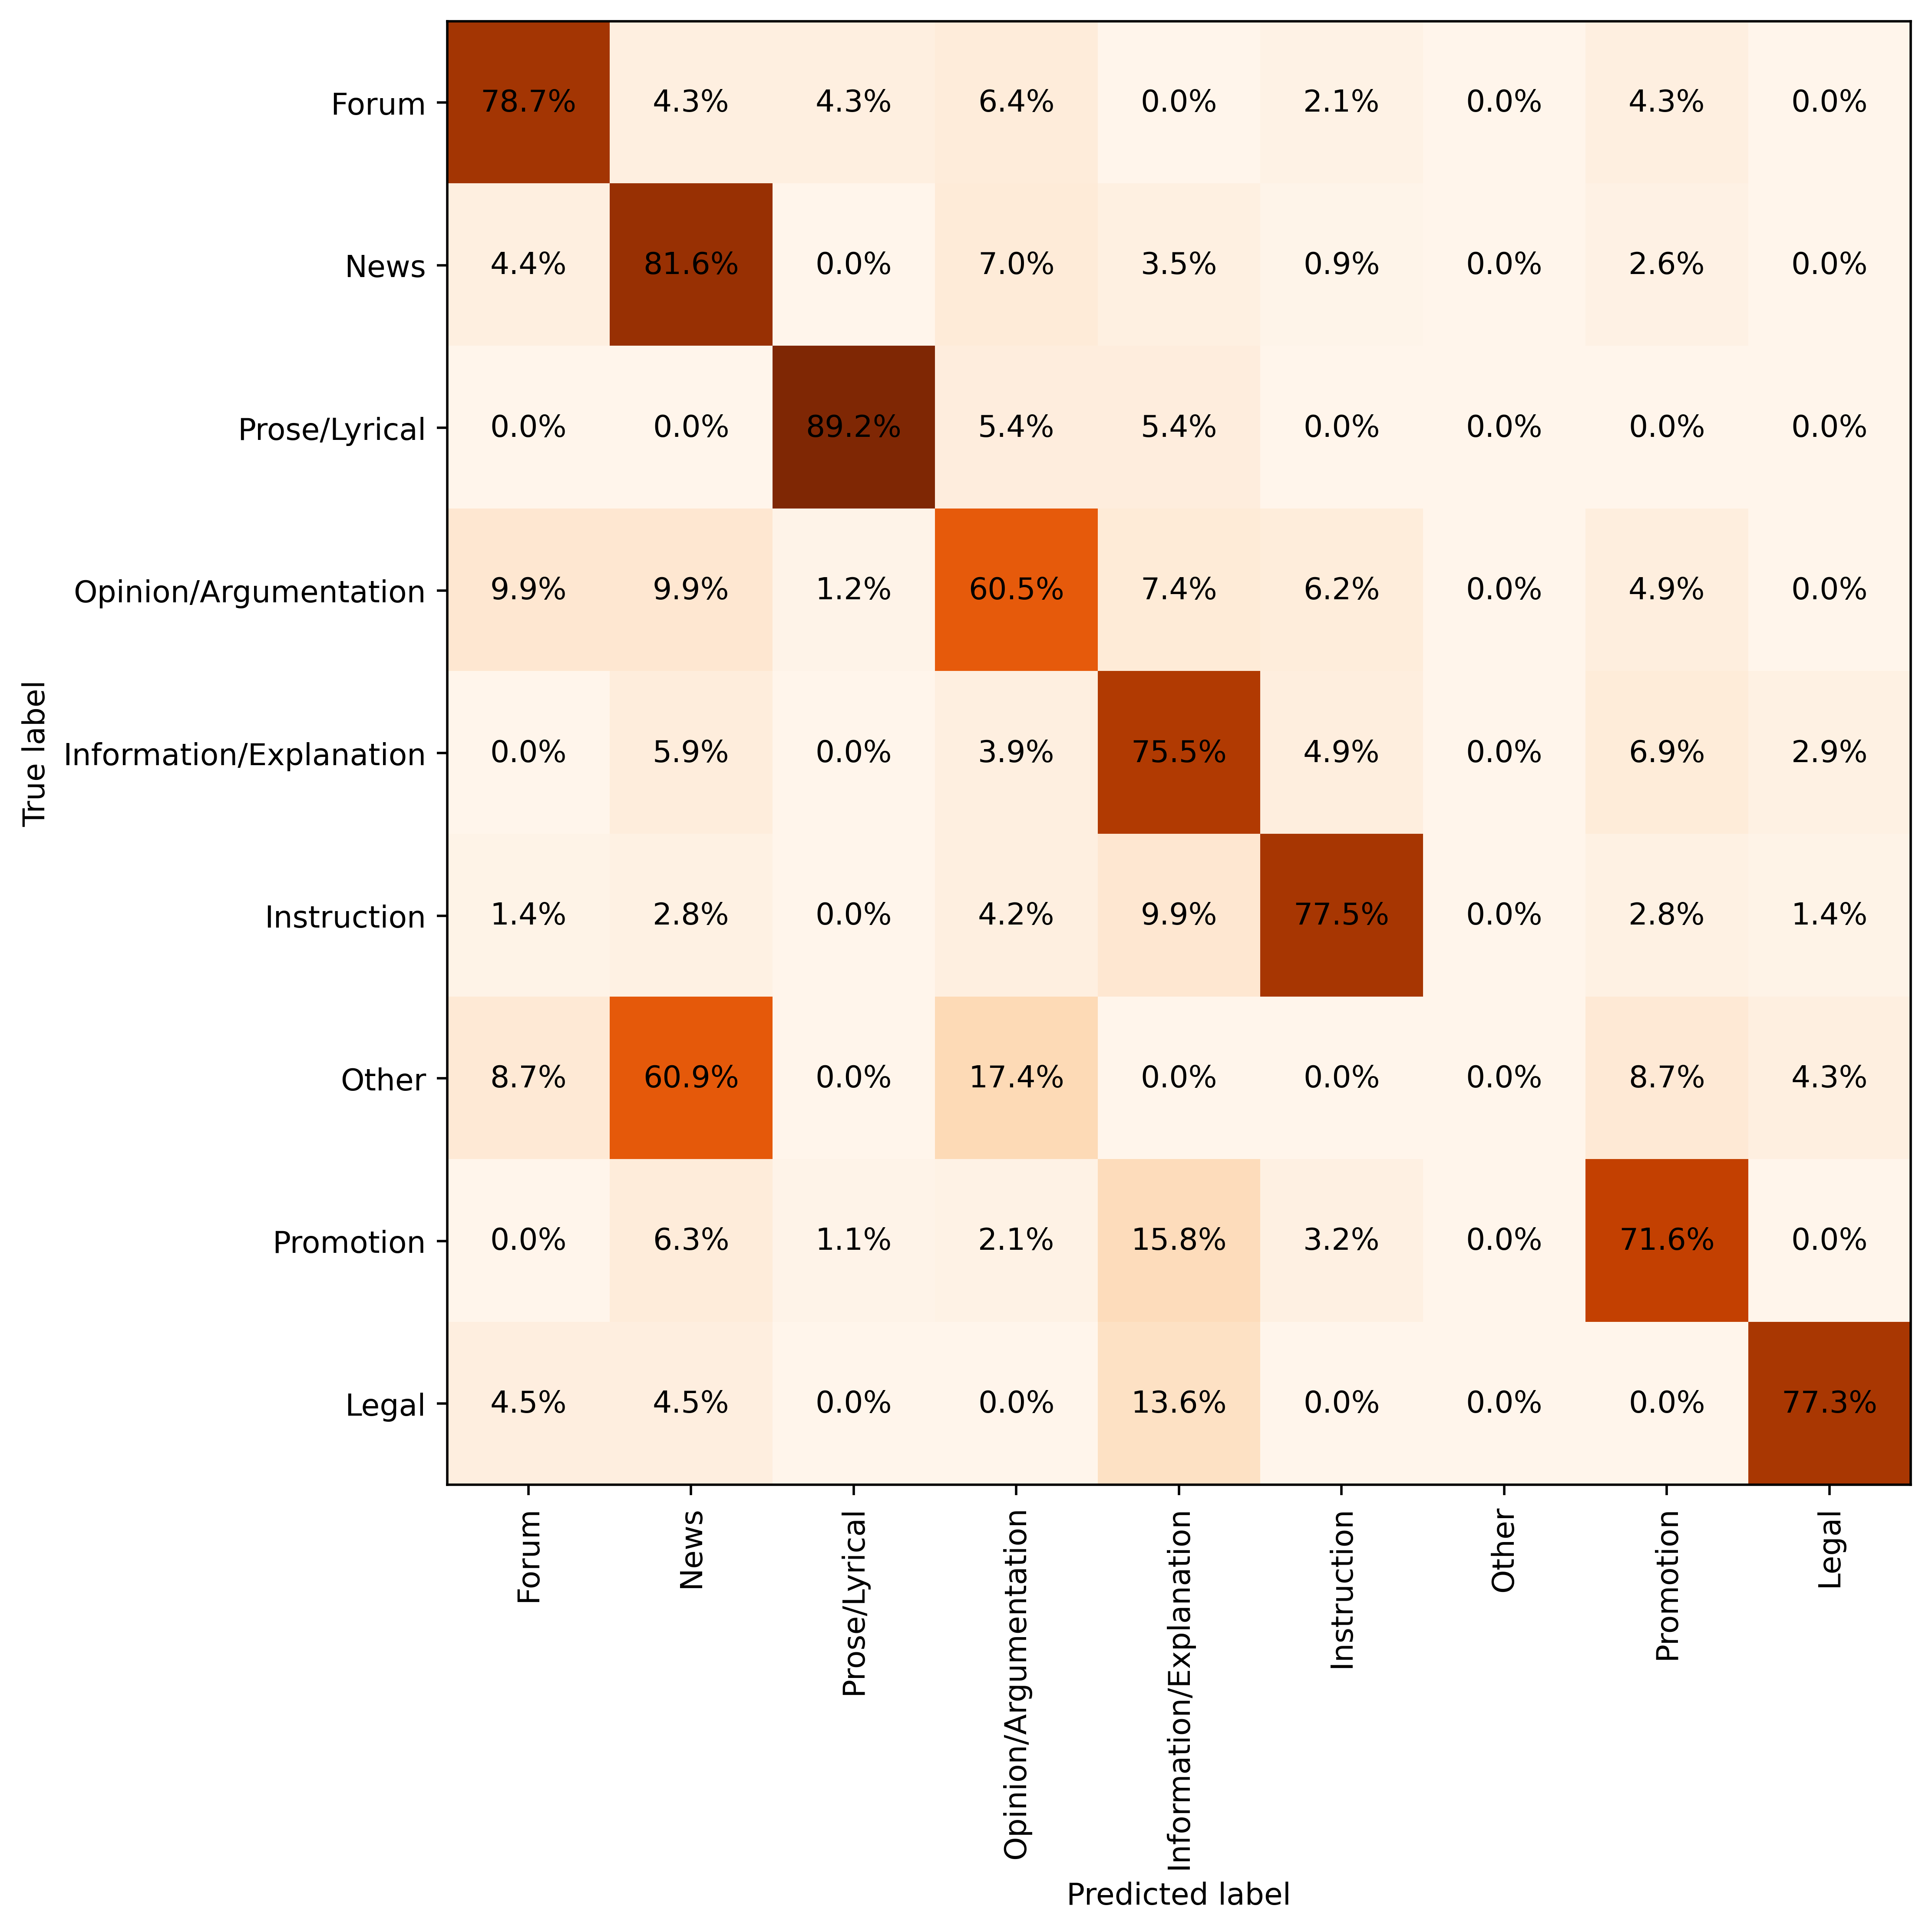

Macro f1: 0.68, Micro f1: 0.731


<Figure size 640x480 with 0 Axes>

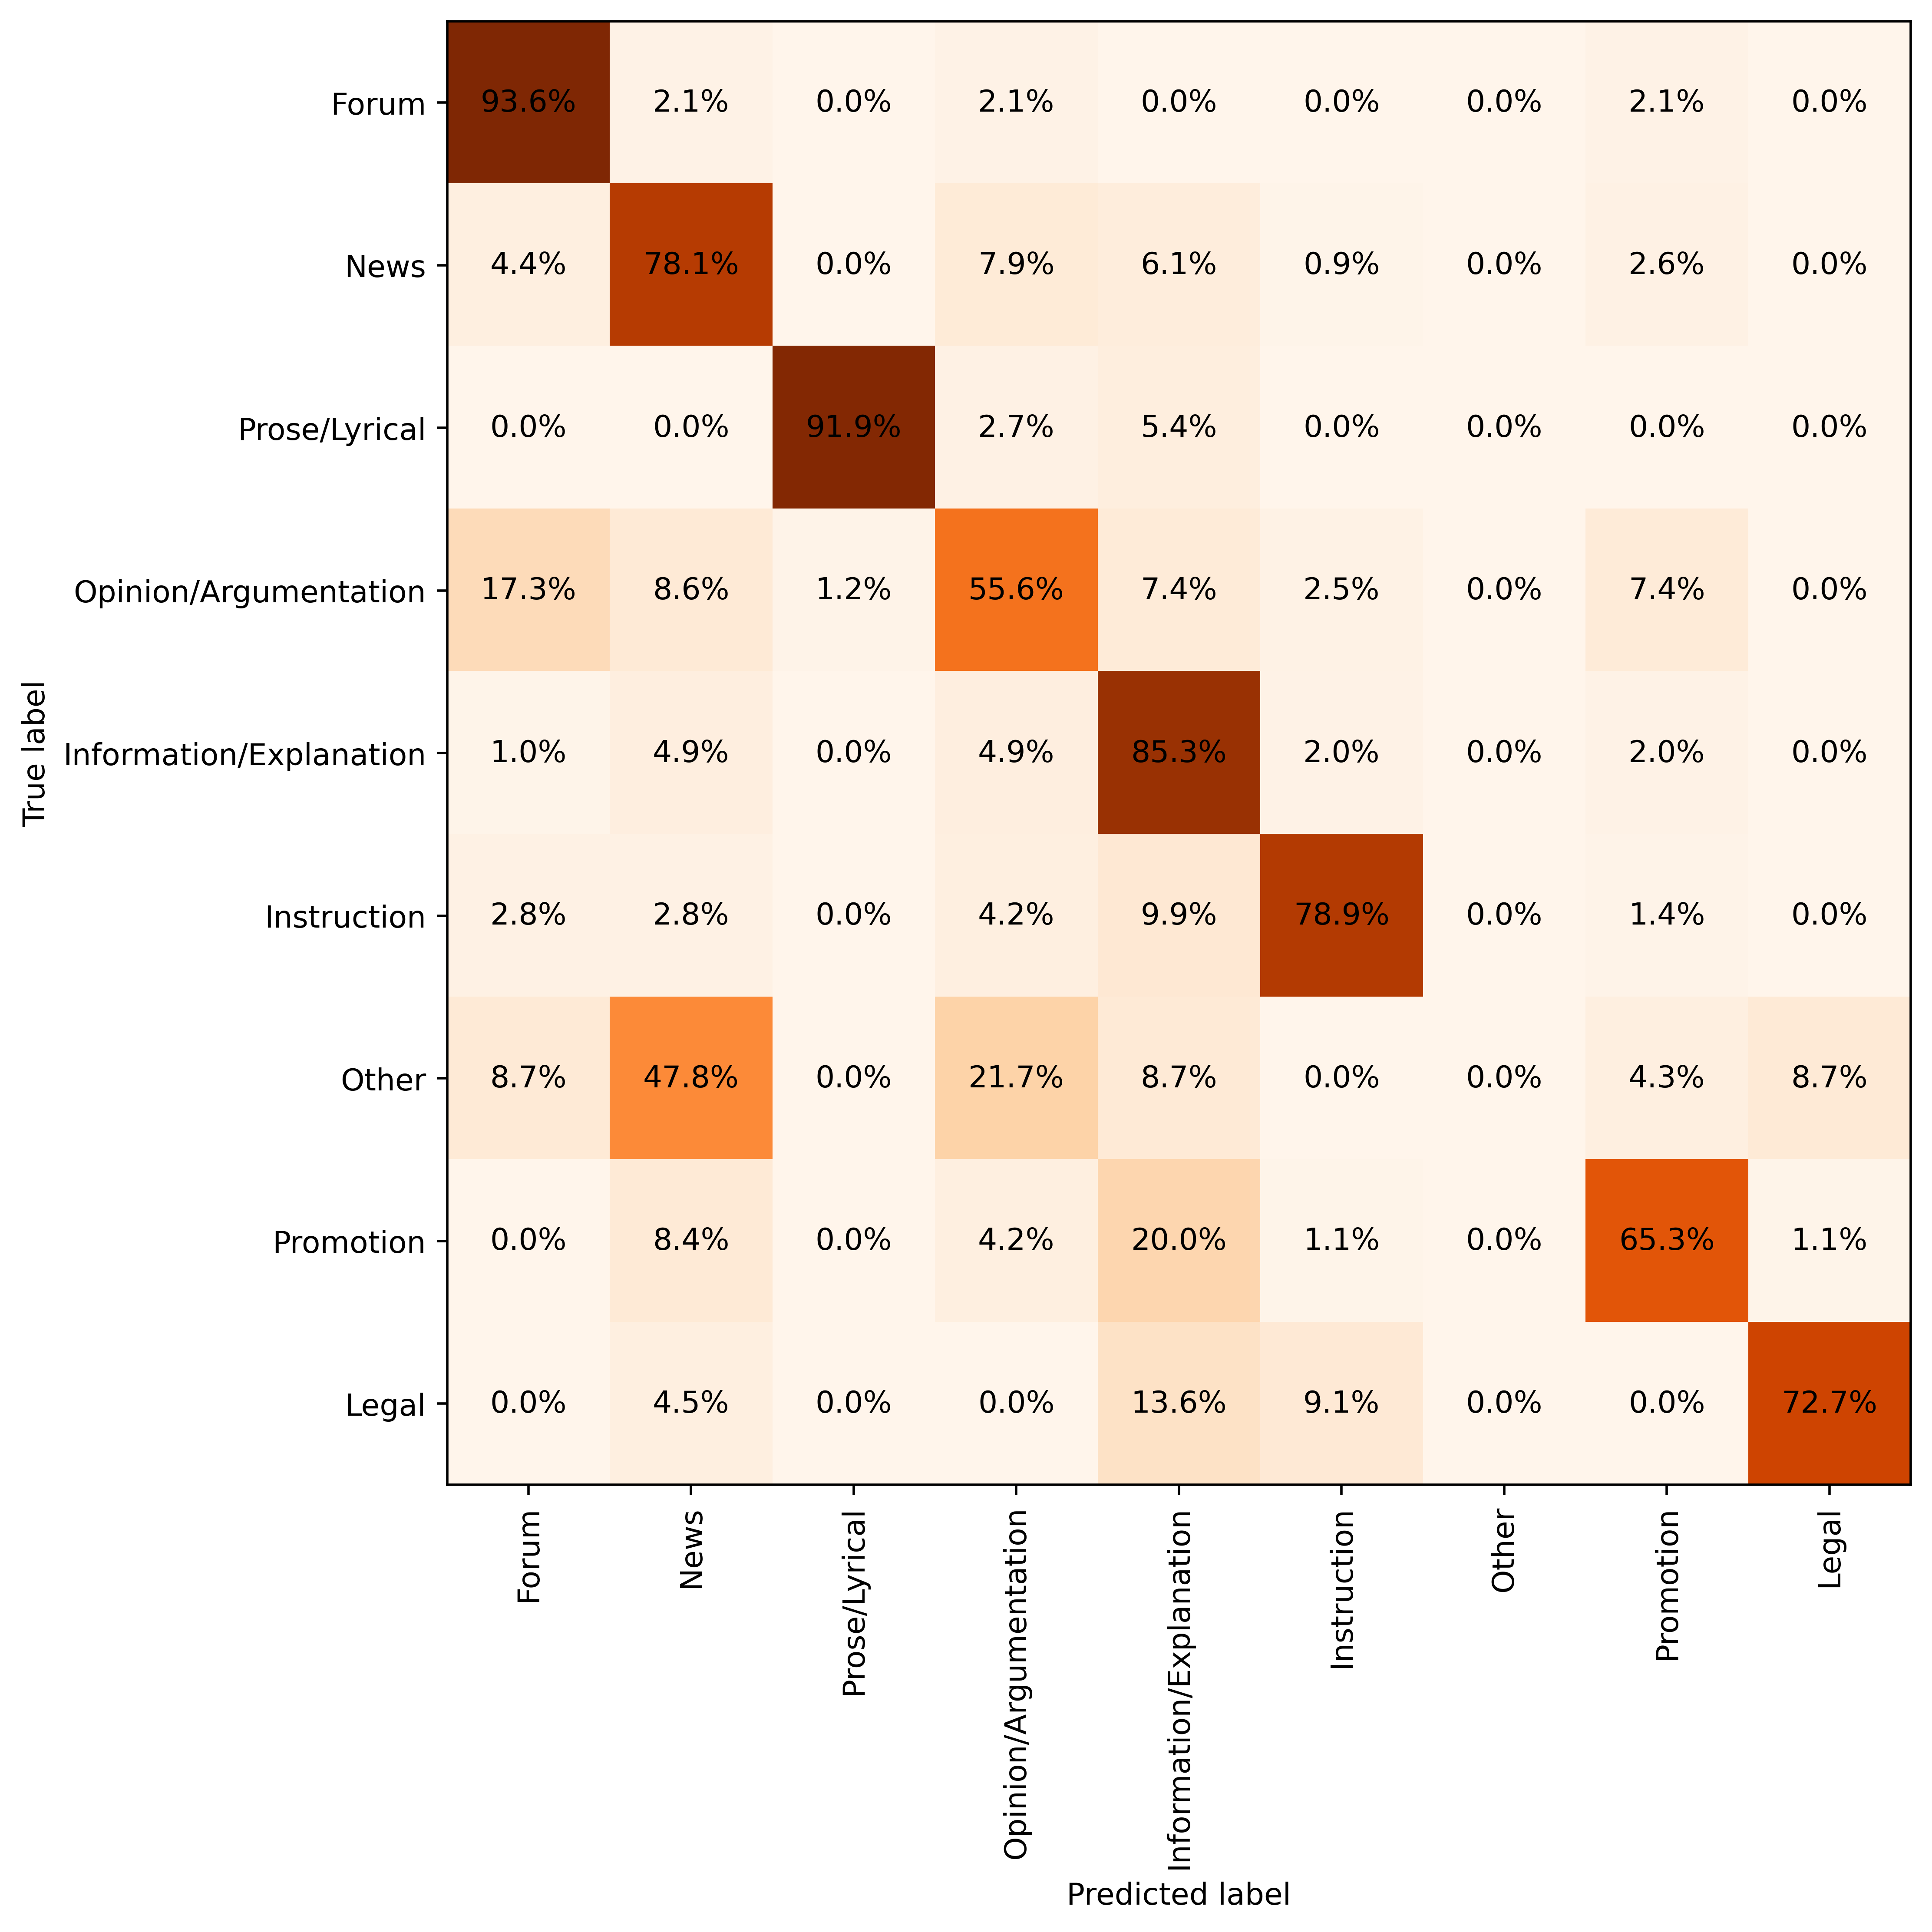

{'micro_F1': 0.731418918918919, 'macro_F1': 0.6797406383423581}

<Figure size 640x480 with 0 Axes>

In [28]:
# Show the confusion matrix for GPT-5 and the student on X-GENRE-test

evaluate(x_genre_test, "labels", "pred_Student-X-GENRE-v1", True)


evaluate(x_genre_test, "labels", "gpt-5-2025-08-07_pred", True)
